In [1]:
# Install kagglehub to download the dataset
!pip install kagglehub -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random

# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Download the Flowers Recognition dataset
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
print("Dataset downloaded to:", path)

# List contents
all_items = os.listdir(path)
print("Contents of dataset root:", all_items)

# Find the correct folder containing class subfolders
dataset_root = None
for item in all_items:
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        sub_items = os.listdir(item_path)
        # Check if this folder contains subfolders (likely class folders)
        if len(sub_items) > 0:
            all_are_dirs = all(os.path.isdir(os.path.join(item_path, s)) for s in sub_items)
            if all_are_dirs:
                dataset_root = item_path
                break

# If no such folder found, use root path
if dataset_root is None:
    dataset_root = path

print(f"Using dataset root: {dataset_root}")

# Get class names
class_names = sorted([d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))])
num_classes = len(class_names)
print(f"\nTotal classes: {num_classes}")
print(f"Classes: {class_names}")

100%|██████████| 225M/225M [00:06<00:00, 38.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2
Contents of dataset root: ['flowers']
Using dataset root: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers

Total classes: 5
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [3]:
# Set image size
size = 128

# Data augmentation for training (helps prevent overfitting)
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for test
val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset without any transform first
full_dataset_raw = datasets.ImageFolder(root=dataset_root, transform=None)

# Split indices (80% train, 20% test)
total_size = len(full_dataset_raw)
indices = list(range(total_size))
random.shuffle(indices)
split_idx = int(0.8 * total_size)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

# Custom Dataset wrapper to apply transform on the fly
class CustomSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

# Create train and test datasets with different transforms
train_dataset = CustomSubset(full_dataset_raw, train_indices, transform=train_transform)
test_dataset = CustomSubset(full_dataset_raw, test_indices, transform=val_transform)

# Hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 20

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 3453
Test samples: 864


In [4]:
# Define the CNN model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize the model
model = CNNModel(num_classes).to(device)

# Print model summary
from torchsummary import summary
summary(model, (3, size, size))

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTOTAL TRAINABLE PARAMETERS: {total_params:,}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

In [5]:
# Define loss function, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total
    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total
    return val_loss, val_acc

# Lists to store metrics
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


STARTING TRAINING

Epoch 1/20, LR: 0.001
Train Loss: 2.3253 | Train Acc: 0.3438
Val Loss: 1.2919 | Val Acc: 0.4236

Epoch 2/20, LR: 0.000993844
Train Loss: 1.3472 | Train Acc: 0.3959
Val Loss: 1.2237 | Val Acc: 0.4815

Epoch 3/20, LR: 0.000975528
Train Loss: 1.3123 | Train Acc: 0.4202
Val Loss: 1.1956 | Val Acc: 0.5046

Epoch 4/20, LR: 0.000945503
Train Loss: 1.2912 | Train Acc: 0.4304
Val Loss: 1.1924 | Val Acc: 0.5289

Epoch 5/20, LR: 0.000904508
Train Loss: 1.2507 | Train Acc: 0.4558
Val Loss: 1.1296 | Val Acc: 0.5301

Epoch 6/20, LR: 0.000853553
Train Loss: 1.2571 | Train Acc: 0.4451
Val Loss: 1.1233 | Val Acc: 0.5579

Epoch 7/20, LR: 0.000793893
Train Loss: 1.2187 | Train Acc: 0.4802
Val Loss: 1.1166 | Val Acc: 0.5278

Epoch 8/20, LR: 0.000726995
Train Loss: 1.1965 | Train Acc: 0.4770
Val Loss: 1.1003 | Val Acc: 0.5394

Epoch 9/20, LR: 0.000654508
Train Loss: 1.1929 | Train Acc: 0.5088
Val Loss: 1.0470 | Val Acc: 0.5984

Epoch 10/20, LR: 0.000578217
Train Loss: 1.1468 | Train Acc

In [6]:
# Evaluate on the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate final test accuracy
test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*60}")

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


FINAL TEST ACCURACY: 0.6632 (66.32%)

Detailed Classification Report:
              precision    recall  f1-score   support

       daisy       0.68      0.66      0.67       147
   dandelion       0.68      0.73      0.70       220
        rose       0.62      0.48      0.54       151
   sunflower       0.67      0.77      0.72       150
       tulip       0.64      0.65      0.65       196

    accuracy                           0.66       864
   macro avg       0.66      0.66      0.66       864
weighted avg       0.66      0.66      0.66       864



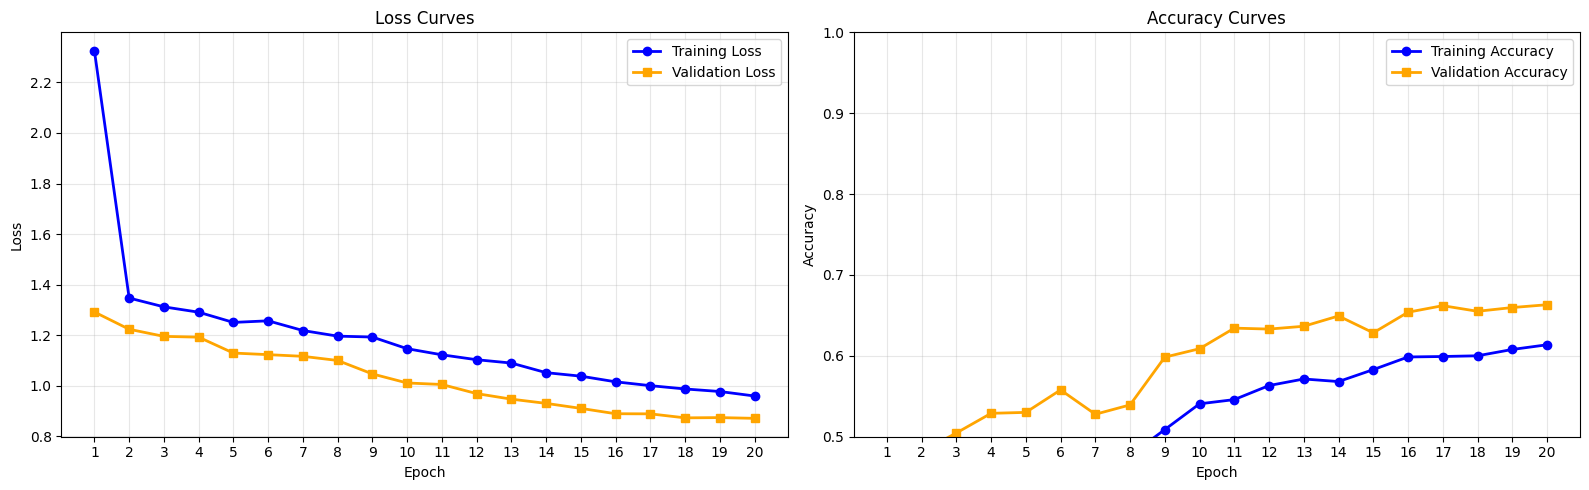


TRAINING SUMMARY
Best Validation Accuracy: 66.32% (Epoch 20)
Final Test Accuracy: 66.32%
Best Validation Loss: 0.8714


In [7]:
# Plot Training and Validation Curves
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss Curves
ax1.plot(epochs_range, train_losses, 'o-', color='blue', linewidth=2, markersize=6, label='Training Loss')
ax1.plot(epochs_range, val_losses, 's-', color='orange', linewidth=2, markersize=6, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# Accuracy Curves
ax2.plot(epochs_range, train_accuracies, 'o-', color='blue', linewidth=2, markersize=6, label='Training Accuracy')
ax2.plot(epochs_range, val_accuracies, 's-', color='orange', linewidth=2, markersize=6, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Best Validation Accuracy: {max(val_accuracies)*100:.2f}% (Epoch {np.argmax(val_accuracies)+1})")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Best Validation Loss: {min(val_losses):.4f}")
print("="*60)

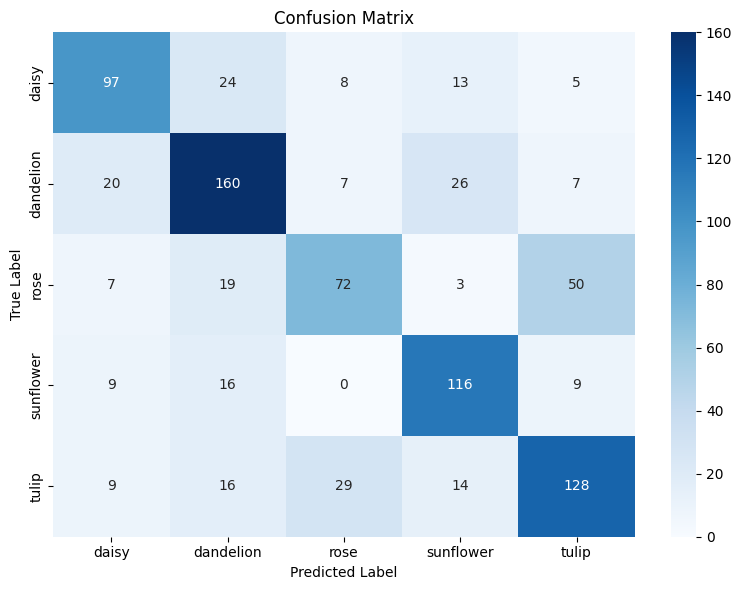

In [8]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [9]:
# Save the trained model weights
torch.save(model.state_dict(), 'model_weights.pth')
print("Model weights saved as 'model_weights.pth'")

# Download the file to your local machine (optional)
from google.colab import files
files.download('model_weights.pth')

Model weights saved as 'model_weights.pth'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>